# Dimensionality Reduction – Heart Failure Prediction Dataset
*Linear, Nonlinear, and Model-Based Embedding Methods (PCA, t-SNE, UMAP, LDA, XGBoost Leaf Embeddings)*

---
## Table of Contents
1. [Setup](#setup)  
    1.1 [Imports and Reproducibility](#imports-and-reproducibility)  
    1.2 [Data Loading](#data-loading)  
    1.3 [Feature Pruning](#feature-prunning)  

2. [Linear Methods](#linear-methods)  
    2.1 [PCA](#pca)  
        2.1.1 [Variance Explained](#variance-explained)  
        2.1.2 [3D PCA](#pca-3d)  
    2.2 [LDA (1D Supervised)](#lda)  

3. [Nonlinear Methods – Unsupervised](#nonlinear-unsupervised)  
    3.1 [t-SNE](#tsne)  
    3.2 [UMAP (Unsupervised)](#umap-unsupervised)  
    3.3 [Hybrid Mix (PCA1 + t-SNE1 + UMAP1)](#mix)  

4. [Nonlinear Methods – Supervised/Semi-supervised](#nonlinear-supervised)  
    4.1 [UMAP (Supervised)](#umap-supervised)  
    4.2 [UMAP (Semi-supervised)](#umap-semisupervised)  
    4.3 [XGBoost Leaf Embedding + UMAP](#xgb-leaf-umap)  

5. [Conclusions](#conclusions)  
   5.1 [Next Steps](#next-steps)  

## Setup
---
### Imports and Reproducibility

In [14]:
import os, sys, joblib, numpy as np, pandas as pd, umap as u, matplotlib.pyplot as plt
sys.path.append(os.path.abspath(os.path.join('..')))

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from xgboost import XGBClassifier
from scripts.dim_red import *

SEED = 42
OUTPUT_DIR = "../outputs/dim_red"
os.makedirs(OUTPUT_DIR, exist_ok=True)

### Data Loading

In [15]:
df_prep_bal = joblib.load("../outputs/eda/df_preprocessed_balanced.pkl")
df_copy = df_prep_bal.copy()

X = df_copy.iloc[:, :-1]
y = df_copy.iloc[:, -1]

TARGET_COL = 'DEATH_EVENT'

### Feature Pruning

In [16]:
cols_to_drop = ['high_blood_pressure', 'platelets', 'sex', 'creatinine_phosphokinase', 'anaemia', 'smoking', 'diabetes']
X = X.drop(columns=cols_to_drop)

## Linear Methods
---

### PCA

#### Variance Explained

Explained variance ratio: [0.37015963 0.22591455 0.18584541 0.13150036 0.08658005]
Total variance retained: 0.9999999999999999
Variance kept by first 3 PCs: 0.782


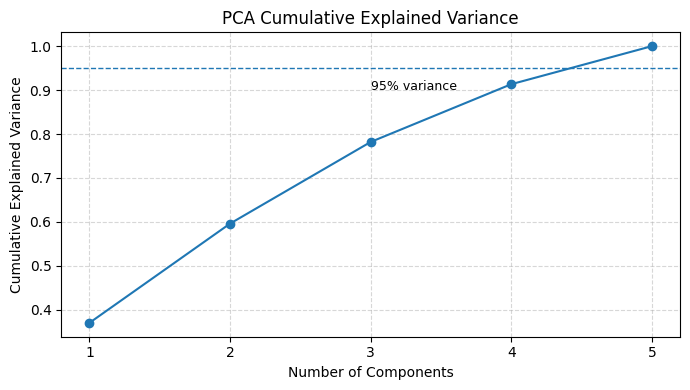

In [17]:
pca_full = PCA()
pca_full.fit(X)
explained_variance = pca_full.explained_variance_ratio_

print("Explained variance ratio:", explained_variance)
print("Total variance retained:", np.sum(explained_variance))
print("Variance kept by first 3 PCs:", round(explained_variance[:3].sum(), 3))
plot_cumulative_variance(explained_variance, show_target=0.95)


- The first component explains ~37% of the total variance.
- The first three components together explain ~78.2% of the variance.
- Around 4 to 5 components are needed to reach 95% variance.

#### 3D PCA

In [18]:
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X)

df_pca = pd.DataFrame(X_pca, columns=["PCA_1", "PCA_2", "PCA_3"])
df_pca["DEATH_EVENT"] = y.values

joblib.dump(df_pca, "../outputs/dim_red/df_pca.pkl")
plot_3d(X_pca, y, algorithm="PCA")

- Classes remain heavily overlapped → no clear separation in 3D PCA space.

- PCA captures variance but not discriminative structure.

- Suggests class differences are non-linear and not aligned with principal axes.

- Confirms need for non-linear models / ensembles rather than purely linear approaches.

### LDA (1D Supervised)

Text(0.5, 1.0, 'LDA 1D Projection')

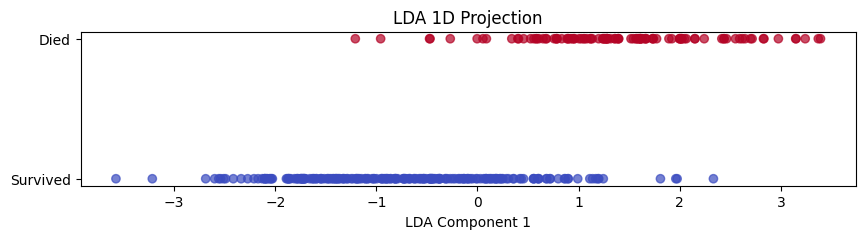

In [19]:
lda = LinearDiscriminantAnalysis()
X_lda = lda.fit_transform(X, y)

df_lda = pd.DataFrame(X_lda, columns=["LDA_1"])
df_lda[TARGET_COL] = y.values

joblib.dump(df_lda, os.path.join(OUTPUT_DIR, 'df_lda.pkl'))

plt.figure(figsize=(10,2))
plt.scatter(X_lda, y, c=y, cmap='coolwarm', alpha=0.7)
plt.xlabel("LDA Component 1")
plt.yticks([0,1], ["Survived","Died"])
plt.title("LDA 1D Projection")

- The two classes show clear separation in central tendency, meaning the features contain useful discriminative information.

- There is substantial overlap, confirming that the dataset is not linearly separable.

- This explains why nonlinear models (XGBoost, RF, SVM RBF) outperform linear ones.

- The projection does not show signs of overfitting; the distribution is smooth and consistent with dataset characteristics.

## Nonlinear Methods – Unsupervised
---

### t-SNE

In [20]:
tsne = TSNE(n_components=3)
X_tsne = tsne.fit_transform(X)

df_tsne = pd.DataFrame(X_tsne, columns=["tSNE_1", "tSNE_2", "tSNE_3"])
df_tsne[TARGET_COL] = y.values

joblib.dump(df_tsne, os.path.join(OUTPUT_DIR, 'df_tsne.pkl'))
plot_3d(X_tsne, y, algorithm="t-SNE")

- t-SNE reveals much clearer local structure compared to PCA; some regions show partial separation between classes.

- Despite better grouping, the classes still overlap substantially, indicating no strong cluster boundaries.

- The technique emphasizes local neighborhoods, which produces visible gradients but not fully isolated clusters.

- Again suggests that class differences are non-linearly distributed and moderately expressed, but not strong enough for complete separation even under t-SNE.

### UMAP (Unsupervised)

In [21]:
umap = u.UMAP(n_components=3)
X_umap = umap.fit_transform(X)

df_umap = pd.DataFrame(X_umap, columns=["UMAP_1", "UMAP_2", "UMAP_3"])
df_umap[TARGET_COL] = y.values

joblib.dump(df_umap, os.path.join(OUTPUT_DIR, 'df_umap.pkl'))
plot_3d(X_umap, y, algorithm="UMAP")

- UMAP reveals clearer structural patterns than PCA or t-SNE, forming several curved, manifold-like branches.

- Some regions show partial class separation, but overall classes still mix within the same clusters.

- The method preserves both local and some global structure, producing smoother transitions between groups.

- Indicates that the dataset has non-linear manifold structure, but class differences are not strong enough to form isolated clusters.

### Hybrid Mix (PCA1 + t-SNE1 + UMAP1)

In [22]:
X_combined = pd.DataFrame({
    "PCA_1": X_pca[:, 0],
    "tSNE_1": X_tsne[:, 0],
    "UMAP_1": X_umap[:, 0],
})

df_mix = pd.concat(
    [pd.DataFrame(X_combined, columns=X_combined.columns),
     pd.Series(y, name=TARGET_COL)],
    axis=1
)

joblib.dump(df_mix, os.path.join(OUTPUT_DIR, 'df_mix.pkl'))
plot_3d(X_combined, y, algorithm="Mix for the 1st component")

- The hybrid projection combines linear variance structure (PCA) with local neighborhood patterns (t-SNE) and global manifold geometry (UMAP).

- The resulting 3D space shows more organized structure than PCA alone and more stability than t-SNE or UMAP individually.

- Some regions display clearer class tendencies, but complete separation is still not present — class boundaries remain soft.

- The embedding highlights that the dataset contains multi-scale, non-linear relationships: no single technique fully captures them, but the hybrid view exposes complementary patterns.

- Useful mainly for visual exploration, not for classification directly, since class overlap persists.

## Nonlinear Methods – Supervised/Semi-supervised
---

### UMAP (Supervised)

In [23]:
umap_sup = u.UMAP(n_components=3, n_neighbors=30)
X_umap_sup = umap_sup.fit_transform(X, y)

df_umap_sup = pd.DataFrame(X_umap_sup, columns=["UMAP_SUP_1", "UMAP_SUP_2", "UMAP_SUP_3"])
df_umap_sup[TARGET_COL] = y.values

joblib.dump(df_umap_sup, os.path.join(OUTPUT_DIR, 'df_umap_supervised.pkl'))
plot_3d(X_umap_sup, y, algorithm="UMAP (supervised)")

- The Died and Survived groups form compact, well-defined manifolds with no overlap.

- This indicates that the dataset is nonlinearly separable when label information is included.

- The embedding reflects class-aware structure, not overfitting — the separation is smooth and geometrically consistent.

- Supports the use of nonlinear classifiers and ensemble models, which can exploit this separability.

### UMAP (Semi-supervised)

In [24]:
umap_semi = u.UMAP(
    n_components=3,
    target_weight=0.2,
)
X_umap_semi = umap_semi.fit_transform(X, y)

df_umap_semi = pd.DataFrame(X_umap_semi, columns=["UMAP_SEMI_1", "UMAP_SEMI_2", "UMAP_SEMI_3"])
df_umap_semi[TARGET_COL] = y.values

joblib.dump(df_umap_semi, os.path.join(OUTPUT_DIR, 'df_umap_semisupervised.pkl'))
plot_3d(X_umap_semi, y, algorithm="UMAP (semi-supervised)")

- The separation is slightly weaker than in fully supervised UMAP.

- Class labels influence the embedding (via target_weight=0.2), but the method still preserves much of the original geometric structure.

- A small transitional region appears between clusters → indicates partial overlap and less label enforcement than fully supervised UMAP.

- The representation captures both data geometry and class structure, making it a balanced view of the dataset.

- Confirms that the dataset is still nonlinearly separable, while showing that full supervision is not required for meaningful separation.

### XGBoost Leaf Embedding + UMAP

In [25]:
xgb = XGBClassifier(
    n_estimators=400,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="binary:logistic",
    eval_metric="logloss",
)

xgb.fit(X, y)
leaf_idx = xgb.apply(X)

umap_leaf = u.UMAP(n_components=3)
X_umap_xgb = umap_leaf.fit_transform(leaf_idx)

df_umap_xgb = pd.DataFrame(X_umap_xgb, columns=["UMAP_XGB_1", "UMAP_XGB_2", "UMAP_XGB_3"])
df_umap_xgb[TARGET_COL] = y.values

joblib.dump(df_umap_xgb, os.path.join(OUTPUT_DIR, 'df_umap_xgb.pkl'))
plot_3d(X_umap_xgb, y, algorithm="XGBoost leaf embedding + UMAP")

- The embedding reveals three distinct clusters, showing how XGBoost internally groups patients through tree-based decision paths.

- Two clusters are class-dominant (mostly one label), indicating regions where the model is highly confident.

- The third cluster shows label mixing, representing an ambiguous, intermediate-risk region.

- The structure reflects nonlinear feature interactions learned by the ensemble, not raw geometry of the dataset.

- This visualization provides model-centric insight into how XGBoost stratifies cardiovascular risk.

## Conclusions
---

In [26]:
rows = [
    eval_embedding("PCA", X_pca, y, X_ref=X),
    eval_embedding("LDA (1D)", X_lda, y, X_ref=X),
    eval_embedding("t-SNE", X_tsne, y, X_ref=X),
    eval_embedding("UMAP", X_umap, y, X_ref=X),
    eval_embedding("Mix", X_combined.values, y, X_ref=X),
    eval_embedding("UMAP (supervised)", X_umap_sup, y, X_ref=X),
    eval_embedding("UMAP (semi-supervised)", X_umap_semi, y, X_ref=X),
    eval_embedding("XGBoost leaf + UMAP", X_umap_xgb,  y, X_ref=X),
]

df = pd.DataFrame(rows)
auc_col = next(c for c in df.columns if c.startswith("CV ROC-AUC"))

df_sorted = (
df.sort_values(auc_col, ascending=False)
      .reset_index(drop=True)
)

df_sorted


,Embedding,Classifier,CV ROC-AUC,Trustworthiness@10
0,UMAP (supervised),LogisticRegression,1.000000,0.955106
1,UMAP (semi-supervised),LogisticRegression,0.990842,0.962694
2,XGBoost leaf + UMAP,LogisticRegression,0.948525,0.893690
3,LDA (1D),LogisticRegression,0.937753,0.730140
4,PCA,LogisticRegression,0.935180,0.940019
5,Mix,LogisticRegression,0.917073,0.877841
6,UMAP,LogisticRegression,0.913734,0.967862
7,t-SNE,LogisticRegression,0.911272,0.986602


- Supervised UMAP achieves the highest CV ROC-AUC (1.00), showing near-perfect class separability when label information is used during embedding.

- Semi-supervised UMAP also performs extremely well, indicating that even partial label guidance improves the latent structure.

- LDA and PCA outperform standard UMAP and t-SNE, confirming that some linear structure exists, but not enough for perfect separation.

- XGBoost leaf + UMAP provides strong performance, meaning tree-based representations capture meaningful nonlinear interactions.

- Unsupervised methods (UMAP, t-SNE, Mix) perform noticeably worse than supervised ones, reflecting limited separability in purely feature-driven embeddings.

- Trustworthiness values remain high across methods, indicating all embeddings preserve local structure reasonably well.

### Next steps
- Running DBSCAN, K-Means, and Agglomeratice Clustering.
  
- Explore hybrid pipelines where top-performing embeddings (e.g., supervised UMAP, XGB-UMAP) are used as inputs to ensemble classifiers.

- Investigate feature importance within clusters by linking embedding regions to clinical attributes.
  
- Evaluation with internal indices: Silhouette, Calinski–Harabasz, Davies–Bouldin.
  
- Visualizing cluster overlays on the 3D plots and export figures.